In [2]:

using ITensors
using ITensorMPS
using JLD2
using Plots
using LaTeXStrings
using Printf
using Polynomials
using Statistics
using GLM
using DataFrames




In [3]:


data_dir = joinpath(@__DIR__, "data")

# all_data[truncation][sigma] = loaded_data_dict 
all_data = Dict{Float64, Dict{Float64, Any}}() 

sigma_values = [0.0, 5e-7, 6e-7, 7e-7, 8e-7, 9e-7, 1e-6, 1.2e-6, 1.4e-6, 1.6e-6, 1.8e-6, 2e-6, 2.2e-6, 2.4e-6, 2.6e-6, 2.8e-6, 3e-6, 4e-6, 5e-6, 1e-5, 1e-4, 1e-3, 1e-2, 2e-2, 1e-1, 2e-1, 5e-1, 7e-1, 1.0, 1.5, 2.0, 3.0, 5.0]

trunc_values = [1e-16, 8e-15, 6e-15, 4e-15, 2e-15, 1e-15, 8e-14, 6e-14, 1e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8] 

for trunc in trunc_values
    all_data[trunc] = Dict{Float64, Any}()
    
    for σ in sigma_values
        trunc_str = @sprintf("%.1e", trunc)
        
        # Explicitly format the clean case string
        if σ == 0.0
            sigma_str = "0.0e+00"
        else
            sigma_str = @sprintf("%.1e", σ)
        end

        file_name = "data_fid_$(trunc_str)_$(sigma_str).jld2" 
        file_path = joinpath(data_dir, file_name) 
        
        if isfile(file_path) 
            try
                data = load(file_path)
                all_data[trunc][σ] = data 
                println("Successfully loaded: Trunc=$trunc_str, σ=$sigma_str")
            catch e
                println("ERROR loading file: $file_name -> $e")
            end
        else
            println("File not found: $file_name") 
        end
    end
end


Successfully loaded: Trunc=1.0e-16, σ=0.0e+00
Successfully loaded: Trunc=1.0e-16, σ=5.0e-07
Successfully loaded: Trunc=1.0e-16, σ=6.0e-07
Successfully loaded: Trunc=1.0e-16, σ=7.0e-07
Successfully loaded: Trunc=1.0e-16, σ=8.0e-07
Successfully loaded: Trunc=1.0e-16, σ=9.0e-07
Successfully loaded: Trunc=1.0e-16, σ=1.0e-06
Successfully loaded: Trunc=1.0e-16, σ=1.2e-06
Successfully loaded: Trunc=1.0e-16, σ=1.4e-06
Successfully loaded: Trunc=1.0e-16, σ=1.6e-06
Successfully loaded: Trunc=1.0e-16, σ=1.8e-06
Successfully loaded: Trunc=1.0e-16, σ=2.0e-06
Successfully loaded: Trunc=1.0e-16, σ=2.2e-06
Successfully loaded: Trunc=1.0e-16, σ=2.4e-06
Successfully loaded: Trunc=1.0e-16, σ=2.6e-06
Successfully loaded: Trunc=1.0e-16, σ=2.8e-06
Successfully loaded: Trunc=1.0e-16, σ=3.0e-06
Successfully loaded: Trunc=1.0e-16, σ=4.0e-06
Successfully loaded: Trunc=1.0e-16, σ=5.0e-06
Successfully loaded: Trunc=1.0e-16, σ=1.0e-05
Successfully loaded: Trunc=1.0e-16, σ=1.0e-04
Successfully loaded: Trunc=1.0e-16

In [4]:
function unfold_spectrum(s)
    n_vals = length(s) 
    x_vals = zeros(Int, n_vals)
    y_vals = zeros(Float64, n_vals)

    if n_vals > 0
        x_vals[1] = 0 
        y_vals[1] = s[1]
    end

    for i in 2:n_vals
        step = div(i,2)
        sgn = iseven(i) ? 1 : -1
        x_vals[i] = sgn * step
        y_vals[i] = s[i]
    end

    perm = sortperm(x_vals)
    return x_vals[perm], y_vals[perm]
end


function get_unfolded_data(raw_spectra)
    valid_spectra = filter(x -> x > 0, raw_spectra)
    isempty(valid_spectra) && return Float64[], Float64[]
    return unfold_spectrum(sort(valid_spectra, rev=true))
end

get_unfolded_data (generic function with 1 method)

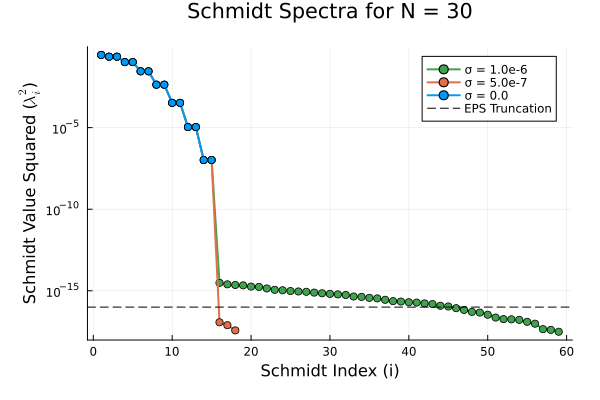

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\spectra_dis_N=30.png"

In [5]:
target_sigmas = [0.0, 5e-7, 1e-6] 
target_trunc = 1e-16
target_N = 30

p_spectra = plot(
    title = "Schmidt Spectra for N = $target_N",
    xlabel = "Schmidt Index (i)",
    ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
    legend = :topright,
    yscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for σ in sort(target_sigmas, rev=true) 
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        
        idx = findfirst(==(target_N), N_full)
        
        if !isnothing(idx)
            spectra = data["spectra_avg"][idx, :]
            
            valid_spectra = filter(x -> x > 0, spectra)
            
            sorted_spectra = sort(valid_spectra, rev=true)

            if σ == 0.0
                palette_idx = 1
            elseif σ == 5e-7
                palette_idx = 2 
            else
                palette_idx = 3  
            end
            
            plot!(p_spectra, 1:length(sorted_spectra), sorted_spectra, 
                label = "σ = $(σ)", 
                marker = :circle, 
                color = palette_idx,
                linewidth = 2)
        else
            println("Warning: N = $target_N not found for Trunc = $target_trunc, σ = $σ")
        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

hline!(p_spectra, [1e-16], label = "EPS Truncation", linestyle = :dash, color = :black)

display(p_spectra)
savefig(p_spectra, joinpath("images", "spectra_dis_N=$target_N.png"))

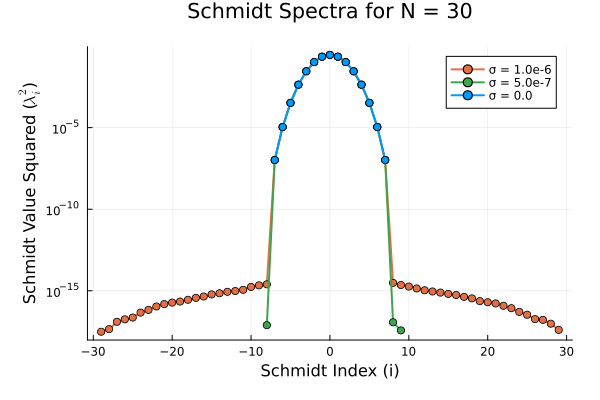

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\spectra_N=30.png"

In [6]:
target_sigmas = [0.0, 5e-7, 1e-6] 
target_trunc = 1e-16
target_N = 30

p_spectra = plot(
    title = "Schmidt Spectra for N = $target_N",
    xlabel = "Schmidt Index (i)",
    ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
    legend = :topright,
    yscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for σ in sort(target_sigmas, rev=true) 
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], σ)
        data = all_data[target_trunc][σ]
        
        N_full = data["N_range"]
        
        idx = findfirst(==(target_N), N_full)
        
        if !isnothing(idx)
            spectra = data["spectra_avg"][idx, :]
            
            valid_spectra = filter(x -> x > 0, spectra)
            
            sorted_spectra = sort(valid_spectra, rev=true)
            N_full, sorted_spectra = unfold_spectrum(sorted_spectra)


            if σ == 1e-6
                palette_idx = 2  
            elseif σ == 5e-7
                palette_idx = 3 
            else
                palette_idx = 1  
            end
            
            plot!(p_spectra, N_full, sorted_spectra, 
                label = "σ = $(σ)", 
                marker = :circle, 
                color = palette_idx,
                linewidth = 2)
        else
            println("Warning: N = $target_N not found for Trunc = $target_trunc, σ = $σ")
        end
    else
        println("Warning: Data not found for Trunc = $target_trunc, σ = $σ")
    end
end

display(p_spectra)
savefig(p_spectra, joinpath("images", "spectra_N=$target_N.png"))

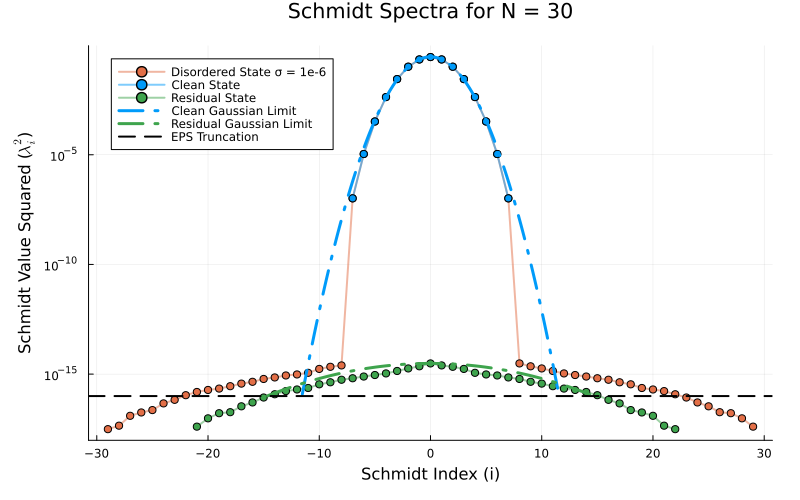

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\spectra_dis_Gaussian_N=30.png"

In [7]:
target_sigmas = [0.0, 1e-6] 
target_trunc = 1e-16
target_N = 30

p_spectra = plot(
    title = "Schmidt Spectra for N = $target_N",
    xlabel = "Schmidt Index (i)",
    ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
    legend = :topleft,
    yscale = :log10,
    margin = 5Plots.mm,
    size = (800, 500),
    grid = true
)

# 1. Initialize empty arrays to hold the raw spectra
clean_spectra = Float64[]
disordered_spectra = Float64[]

# 2. Fetch Clean Data 
if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], 0.0)
    data_clean = all_data[target_trunc][0.0]
    idx_clean = findfirst(==(target_N), data_clean["N_range"])
    if !isnothing(idx_clean)
        clean_spectra = data_clean["spectra_avg"][idx_clean, :]
    end
end

# 3. Fetch Disordered Data
if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], 1e-6)
    data_dis = all_data[target_trunc][1e-6]
    idx_dis = findfirst(==(target_N), data_dis["N_range"])
    if !isnothing(idx_dis)
        disordered_spectra = data_dis["spectra_avg"][idx_dis, :]
    end
end

# 4. Extract the Residual Spectrum 
residual_spectra = Float64[]
if !isempty(clean_spectra) && !isempty(disordered_spectra)
    for i in 1:length(disordered_spectra)
        d_val = disordered_spectra[i]
        c_val = clean_spectra[i]
        
        if d_val > 0.0 && (c_val == 0.0 || d_val / c_val > 10.0)
            push!(residual_spectra, d_val)
        end
    end
end

# 5. Helper function to unfold data symmetrically
function get_unfolded_data(raw_spectra)
    valid_spectra = filter(x -> x > 0, raw_spectra)
    if isempty(valid_spectra)
        return Float64[], Float64[]
    end
    sorted_spectra = sort(valid_spectra, rev=true)
    return unfold_spectrum(sorted_spectra)
end

# 6. Analytical Clean Gaussian (Exact Hypergeometric Limit)
function get_clean_analytical(N::Int)
    sigma_sq_clean = N / 16.0
    amp_clean = 4.0 / sqrt(2.0 * pi * N)
    return sigma_sq_clean, amp_clean
end

# 7. Analytical Residual Gaussian
function get_residual_analytical(res_x, res_y)
    if isempty(res_y)
        return 0.0, 0.0
    end
    weight_res = sum(res_y)
    sigma_sq_res = sum((res_x .^ 2) .* res_y) / weight_res
    amp_res = maximum(res_y)
    return sigma_sq_res, amp_res
end

# 8. Function to generate plottable continuous curves safely
function generate_gaussian_curves(N::Int, res_x, res_y, min_limit::Float64)
    sig_sq_c, amp_c = get_clean_analytical(N)
    sig_sq_r, amp_r = get_residual_analytical(res_x, res_y)
    
    # Safely calculate the maximum plotting domain to prevent DomainErrors
    bound_x = 0.0
    if amp_c > min_limit
        bound_x = max(bound_x, sqrt(-2.0 * sig_sq_c * log(min_limit / amp_c)))
    end
    if amp_r > min_limit
        bound_x = max(bound_x, sqrt(-2.0 * sig_sq_r * log(min_limit / amp_r)))
    end
    
    if bound_x == 0.0
        return Float64[], Float64[], Float64[], Float64[]
    end
    
    x_smooth = range(-bound_x, bound_x, length=500)
    
    y_clean_curve = Float64[]
    y_res_curve = Float64[]
    y_total_curve = Float64[]
    x_valid = Float64[]
    
    for x in x_smooth
        # Compute pure analytical components
        yc = amp_c * exp(-x^2 / (2 * sig_sq_c))
        yr = sig_sq_r > 0 ? amp_r * exp(-x^2 / (2 * sig_sq_r)) : 0.0
        ytot = yc + yr
        
        # Only keep points that exist at or above the threshold
        if ytot >= min_limit || yc >= min_limit || yr >= min_limit
            push!(x_valid, x)
            # Apply individual cutoffs so curves don't trail into the void
            push!(y_clean_curve, yc >= min_limit ? yc : NaN)
            push!(y_res_curve, yr >= min_limit ? yr : NaN)
            push!(y_total_curve, ytot >= min_limit ? ytot : NaN)
        end
    end
    
    return x_valid, y_clean_curve, y_res_curve, y_total_curve
end

# 9. Unfold discrete data
x_clean, y_clean = get_unfolded_data(clean_spectra)
x_dis, y_dis = get_unfolded_data(disordered_spectra)
x_res, y_res = get_unfolded_data(residual_spectra)

# 10. Generate Continuous Analytical Limits
x_theory, y_theory_clean, y_theory_res, y_theory_total = generate_gaussian_curves(target_N, x_res, y_res, target_trunc)

# 11. Plot Discrete Data Points
if !isempty(x_dis)
    plot!(p_spectra, x_dis, y_dis, label = "Disordered State σ = 1e-6", marker = :circle, color = 2, linewidth = 2, linealpha=0.5)
end
if !isempty(x_clean)
    plot!(p_spectra, x_clean, y_clean, label = "Clean State", marker = :circle, color = 1, linewidth = 2, linealpha=0.5)
end
if !isempty(x_res)
    plot!(p_spectra, x_res, y_res, label = "Residual State", marker = :circle, color = 3, linewidth = 2, linealpha=0.5)
end

# 12. Plot Continuous Analytical Curves Overlaid
if !isempty(x_theory)
    # The Black Hypergeometric Limit
    plot!(p_spectra, x_theory, y_theory_clean, label = "Clean Gaussian Limit", linestyle = :dashdot, color = :1, linewidth = 3)

    # The Isolated Residual Limit
    plot!(p_spectra, x_theory, y_theory_res, label = "Residual Gaussian Limit", linestyle = :dashdot, color = :3, linewidth = 3)
end

# 13. Plot the truncation threshold line
hline!(p_spectra, [target_trunc], 
    label = "EPS Truncation", 
    linestyle = :dash, 
    linecolor = :black, 
    linewidth = 2)

display(p_spectra)
savefig(p_spectra, joinpath("images", "spectra_dis_Gaussian_N=$(target_N).png"))

Plots.AnimatedGif("c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\spectra_and_bd_evolution.gif")
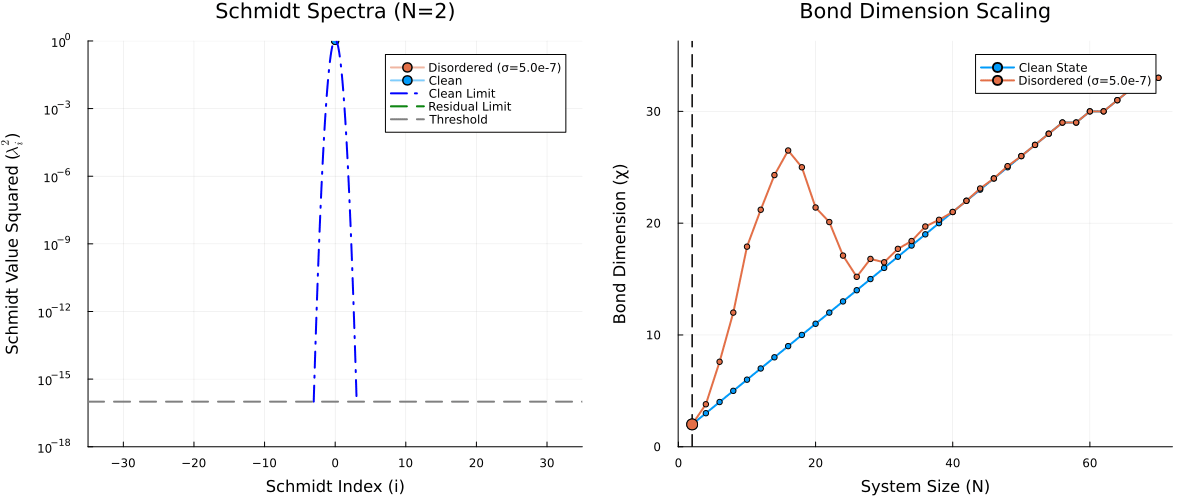

[ Info: Saved animation to c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Fidelity\images\spectra_and_bd_evolution.gif


In [8]:
using Plots

target_sigmas = [0.0, 5e-7] 
target_trunc = 1e-16
target_N_limit = 70  # <-- Set your maximum N limit here

# Dynamically grab the disordered sigma from your array
disorder_sigma = target_sigmas[2]

# 1. Extract the available N values from your dataset
N_vals = all_data[target_trunc][0.0]["N_range"]

# 2. Extract global bond dimension arrays for the subplot using the dynamic sigma
bd_clean = all_data[target_trunc][0.0]["avg_arr"]
bd_disordered = all_data[target_trunc][disorder_sigma]["avg_arr"]

# Ensure arrays align. If not, crop to the shortest length.
valid_len = min(length(N_vals), length(bd_clean), length(bd_disordered))
N_vals = N_vals[1:valid_len]
bd_clean = bd_clean[1:valid_len]
bd_disordered = bd_disordered[1:valid_len]

# 3. Apply the N limit
valid_indices = findall(x -> x <= target_N_limit, N_vals)
N_vals = N_vals[valid_indices]
bd_clean = bd_clean[valid_indices]
bd_disordered = bd_disordered[valid_indices]

# Define maximum y-limit for the bond dimension plot to keep it static
max_bd = maximum(vcat(bd_clean, bd_disordered)) * 1.1 

# Helper Functions
function get_unfolded_data(raw_spectra)
    valid_spectra = filter(x -> x > 0, raw_spectra)
    isempty(valid_spectra) && return Float64[], Float64[]
    return unfold_spectrum(sort(valid_spectra, rev=true))
end

function get_clean_analytical(N::Int)
    return (N / 16.0), (4.0 / sqrt(2.0 * pi * N))
end

function get_residual_analytical(res_x, res_y)
    isempty(res_y) && return 0.0, 0.0
    weight_res = sum(res_y)
    sigma_sq_res = sum((res_x .^ 2) .* res_y) / weight_res
    return sigma_sq_res, maximum(res_y)
end

function generate_gaussian_curves(N::Int, res_x, res_y, min_limit::Float64)
    sig_sq_c, amp_c = get_clean_analytical(N)
    sig_sq_r, amp_r = get_residual_analytical(res_x, res_y)
    
    bound_x = 0.0
    if amp_c > min_limit
        bound_x = max(bound_x, sqrt(-2.0 * sig_sq_c * log(min_limit / amp_c)))
    end
    if amp_r > min_limit
        bound_x = max(bound_x, sqrt(-2.0 * sig_sq_r * log(min_limit / amp_r)))
    end
    
    bound_x == 0.0 && return Float64[], Float64[], Float64[], Float64[]
    
    x_smooth = range(-bound_x, bound_x, length=500)
    
    y_clean_curve, y_res_curve, y_total_curve, x_valid = Float64[], Float64[], Float64[], Float64[]
    
    for x in x_smooth
        yc = amp_c * exp(-x^2 / (2 * sig_sq_c))
        yr = sig_sq_r > 0 ? amp_r * exp(-x^2 / (2 * sig_sq_r)) : 0.0
        ytot = yc + yr
        
        if ytot >= min_limit || yc >= min_limit || yr >= min_limit
            push!(x_valid, x)
            push!(y_clean_curve, yc >= min_limit ? yc : NaN)
            push!(y_res_curve, yr >= min_limit ? yr : NaN)
            push!(y_total_curve, ytot >= min_limit ? ytot : NaN)
        end
    end
    
    return x_valid, y_clean_curve, y_res_curve, y_total_curve
end

# Begin Animation Loop
anim = @animate for (idx, target_N) in enumerate(N_vals)
    
    # ------------------ PLOT 1: THE SPECTRUM ------------------
    p1 = plot(
        title = "Schmidt Spectra (N=$target_N)",
        xlabel = "Schmidt Index (i)",
        ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
        legend = :topright,
        yscale = :log10,
        ylims = (1e-18, 1.0), 
        xlims = (-35, 35), # <-- Fixed x-axis limits
        grid = true
    )

    clean_spectra = Float64[]
    disordered_spectra = Float64[]

    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], 0.0)
        idx_clean = findfirst(==(target_N), all_data[target_trunc][0.0]["N_range"])
        !isnothing(idx_clean) && (clean_spectra = all_data[target_trunc][0.0]["spectra_avg"][idx_clean, :])
    end

    # Dynamically extract disordered data using the updated variable
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], disorder_sigma)
        idx_dis = findfirst(==(target_N), all_data[target_trunc][disorder_sigma]["N_range"])
        !isnothing(idx_dis) && (disordered_spectra = all_data[target_trunc][disorder_sigma]["spectra_avg"][idx_dis, :])
    end

    residual_spectra = Float64[]
    if !isempty(clean_spectra) && !isempty(disordered_spectra)
        for i in 1:length(disordered_spectra)
            d_val, c_val = disordered_spectra[i], clean_spectra[i]
            if d_val > 0.0 && (c_val == 0.0 || d_val / c_val > 10.0)
                push!(residual_spectra, d_val)
            end
        end
    end

    x_clean, y_clean = get_unfolded_data(clean_spectra)
    x_dis, y_dis = get_unfolded_data(disordered_spectra)
    x_res, y_res = get_unfolded_data(residual_spectra)

    x_theory, y_theory_clean, y_theory_res, y_theory_total = generate_gaussian_curves(target_N, x_res, y_res, target_trunc)

    !isempty(x_dis) && plot!(p1, x_dis, y_dis, label = "Disordered (σ=$disorder_sigma)", marker = :circle, color = 2, linewidth = 2, linealpha=0.5)
    !isempty(x_clean) && plot!(p1, x_clean, y_clean, label = "Clean", marker = :circle, color = 1, linewidth = 2, linealpha=0.5)
    !isempty(x_res) && plot!(p1, x_res, y_res, label = "Residual", marker = :circle, color = 3, linewidth = 2, linealpha=0.5)

    if !isempty(x_theory)
        plot!(p1, x_theory, y_theory_clean, label = "Clean Limit", linestyle = :dashdot, color = :blue, linewidth = 2)
        plot!(p1, x_theory, y_theory_res, label = "Residual Limit", linestyle = :dash, color = :green, linewidth = 2)
    end

    hline!(p1, [target_trunc], label = "Threshold", linestyle = :dash, linecolor = :gray, linewidth = 2)

    # ------------------ PLOT 2: THE BOND DIMENSION ------------------
    p2 = plot(
        N_vals, bd_clean,
        label="Clean State",
        xlabel="System Size (N)",
        ylabel="Bond Dimension (χ)",
        title="Bond Dimension Scaling",
        color=1, linewidth=2, marker=:circle, markersize=3,
        ylims=(0, max_bd),
        grid=true,
        legend=:topright
    )
    
    # Update label to show the active sigma parameter
    plot!(p2, N_vals, bd_disordered, label="Disordered (σ=$disorder_sigma)", color=2, linewidth=2, marker=:circle, markersize=3)
    
    # Add dynamic tracking line and points for the current frame
    vline!(p2, [target_N], label="", color=:black, linestyle=:dash, linewidth=1.5)
    
    current_bd_c = bd_clean[idx]
    current_bd_d = bd_disordered[idx]
    scatter!(p2, [target_N, target_N], [current_bd_c, current_bd_d], label="", color=[1, 2], markersize=6)

    # ------------------ COMBINE LAYOUT ------------------
    plot(p1, p2, layout=(1, 2), size=(1200, 500), margin=5Plots.mm)
end

# Save the resulting animation
gif(anim, joinpath("images", "spectra_and_bd_evolution.gif"), fps = 5)

[ Info: Saved animation to c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Fidelity\images\clean_spectra_and_bd_evolution.gif


Plots.AnimatedGif("c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\clean_spectra_and_bd_evolution.gif")
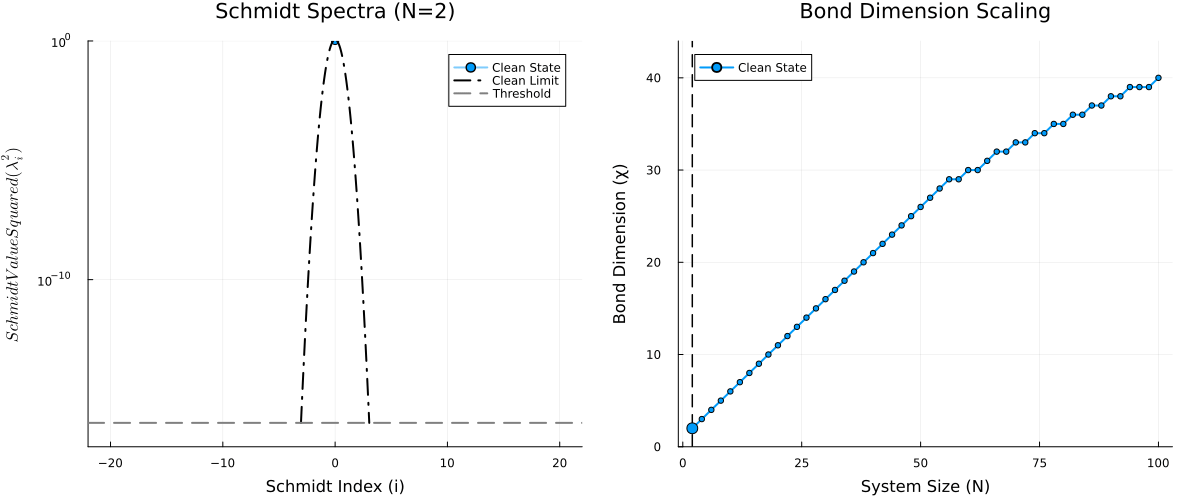

In [9]:
using Plots

target_trunc = 1e-16
target_N_limit = 100

# 1. Extract the available N values and bond dimension from the clean state dataset
N_vals = all_data[target_trunc][0.0]["N_range"]
bd_clean = all_data[target_trunc][0.0]["avg_arr"]

# 2. Apply the N limit
valid_indices = findall(x -> x <= target_N_limit, N_vals)
N_vals = N_vals[valid_indices]
bd_clean = bd_clean[valid_indices]

# Define maximum y-limit for the bond dimension plot to keep it static
max_bd = maximum(bd_clean) * 1.1 

# Helper Functions
function get_unfolded_data(raw_spectra)
    valid_spectra = filter(x -> x > 0, raw_spectra)
    isempty(valid_spectra) && return Float64[], Float64[]
    return unfold_spectrum(sort(valid_spectra, rev=true))
end

function generate_clean_gaussian_curve(N::Int, min_limit::Float64)
    sig_sq_c = N / 16.0
    amp_c = 4.0 / sqrt(2.0 * pi * N)
    
    bound_x = 0.0
    if amp_c > min_limit
        bound_x = sqrt(-2.0 * sig_sq_c * log(min_limit / amp_c))
    end
    
    bound_x == 0.0 && return Float64[], Float64[]
    
    x_smooth = range(-bound_x, bound_x, length=500)
    
    y_clean_curve = Float64[]
    x_valid = Float64[]
    
    for x in x_smooth
        yc = amp_c * exp(-x^2 / (2 * sig_sq_c))
        
        if yc >= min_limit
            push!(x_valid, x)
            push!(y_clean_curve, yc)
        end
    end
    
    return x_valid, y_clean_curve
end

# Begin Animation Loop
anim = @animate for (idx, target_N) in enumerate(N_vals)
    
    # PLOT 1: THE SPECTRUM
    p1 = plot(
        title = "Schmidt Spectra (N=$target_N)",
        xlabel = "Schmidt Index (i)",
        ylabel = L"Schmidt Value Squared (\lambda_{i}^{2})",
        legend = :topright,
        yscale = :log10,
        ylims = (1e-17, 1.0), 
        xlims = (-22, 22), 
        grid = true
    )

    clean_spectra = Float64[]

    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], 0.0)
        idx_clean = findfirst(==(target_N), all_data[target_trunc][0.0]["N_range"])
        !isnothing(idx_clean) && (clean_spectra = all_data[target_trunc][0.0]["spectra_avg"][idx_clean, :])
    end

    x_clean, y_clean = get_unfolded_data(clean_spectra)
    x_theory, y_theory_clean = generate_clean_gaussian_curve(target_N, target_trunc)

    !isempty(x_clean) && plot!(p1, x_clean, y_clean, label = "Clean State", marker = :circle, color = 1, linewidth = 2, linealpha=0.5)

    if !isempty(x_theory)
        plot!(p1, x_theory, y_theory_clean, label = "Clean Limit", linestyle = :dashdot, color = :black, linewidth = 2)
    end

    hline!(p1, [target_trunc], label = "Threshold", linestyle = :dash, linecolor = :gray, linewidth = 2)

    # PLOT 2: THE BOND DIMENSION
    p2 = plot(
        N_vals, bd_clean,
        label="Clean State",
        xlabel="System Size (N)",
        ylabel="Bond Dimension (χ)",
        title="Bond Dimension Scaling",
        color=1, linewidth=2, marker=:circle, markersize=3,
        ylims=(0, max_bd),
        grid=true,
        legend=:topleft
    )
    
    # Add dynamic tracking line and point for the current frame
    vline!(p2, [target_N], label="", color=:black, linestyle=:dash, linewidth=1.5)
    
    current_bd_c = bd_clean[idx]
    scatter!(p2, [target_N], [current_bd_c], label="", color=1, markersize=6)

    # COMBINE LAYOUT
    plot(p1, p2, layout=(1, 2), size=(1200, 500), margin=5Plots.mm)
end

# Save the resulting animation
gif(anim, joinpath("images", "clean_spectra_and_bd_evolution.gif"), fps = 5)

[ Info: Saved animation to c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Fidelity\images\spectra_and_bd_evolution_kbands.gif


Plots.AnimatedGif("c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\spectra_and_bd_evolution_kbands.gif")
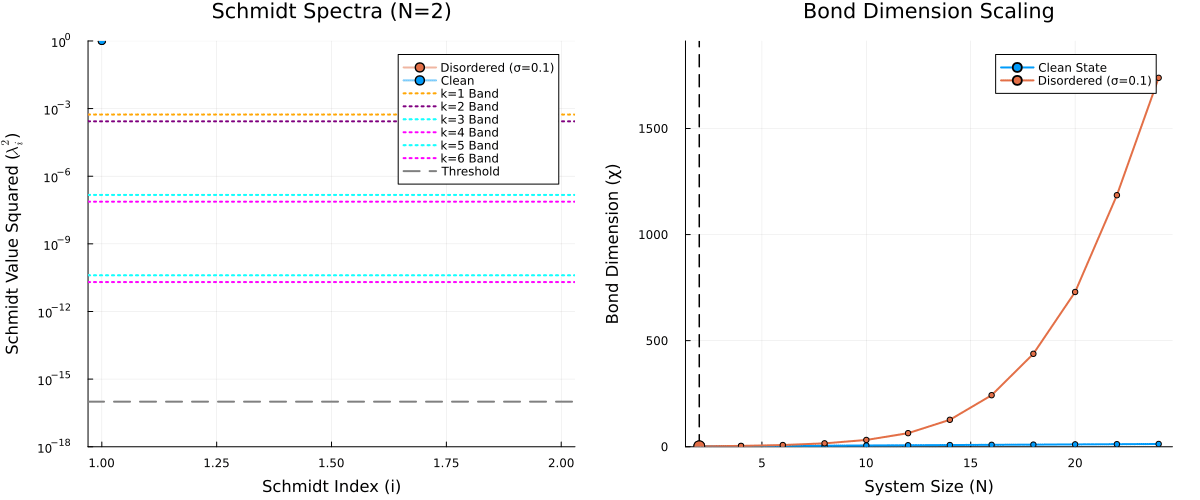

In [10]:


target_sigmas = [0.0, 1e-1] 
target_trunc = 1e-16
target_N_limit = 24

disorder_sigma = target_sigmas[2]

N_vals = all_data[target_trunc][0.0]["N_range"]

bd_clean = all_data[target_trunc][0.0]["avg_arr"]
bd_disordered = all_data[target_trunc][disorder_sigma]["avg_arr"]

valid_len = min(length(N_vals), length(bd_clean), length(bd_disordered))
N_vals = N_vals[1:valid_len]
bd_clean = bd_clean[1:valid_len]
bd_disordered = bd_disordered[1:valid_len]

valid_indices = findall(x -> x <= target_N_limit, N_vals)
N_vals = N_vals[valid_indices]
bd_clean = bd_clean[valid_indices]
bd_disordered = bd_disordered[valid_indices]

max_bd = maximum(vcat(bd_clean, bd_disordered)) * 1.1 

function get_sorted_data(raw_spectra)
    valid_spectra = filter(x -> x > 0, raw_spectra)
    isempty(valid_spectra) && return Float64[], Float64[]
    sorted_spectra = sort(valid_spectra, rev=true)
    return collect(1:length(sorted_spectra)), sorted_spectra
end

anim = @animate for (idx, target_N) in enumerate(N_vals)
    
    p1 = plot(
        title = "Schmidt Spectra (N=$target_N)",
        xlabel = "Schmidt Index (i)",
        ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
        legend = :topright,
        yscale = :log10,
        ylims = (1e-18, 1.0), 
        # xlims = (0, maximum(bd_disordered)),
        grid = true
    )

    clean_spectra = Float64[]
    disordered_spectra = Float64[]

    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], 0.0)
        idx_clean = findfirst(==(target_N), all_data[target_trunc][0.0]["N_range"])
        !isnothing(idx_clean) && (clean_spectra = all_data[target_trunc][0.0]["spectra_avg"][idx_clean, :])
    end

    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], disorder_sigma)
        idx_dis = findfirst(==(target_N), all_data[target_trunc][disorder_sigma]["N_range"])
        !isnothing(idx_dis) && (disordered_spectra = all_data[target_trunc][disorder_sigma]["spectra_avg"][idx_dis, :])
    end

    x_clean, y_clean = get_sorted_data(clean_spectra)
    x_dis, y_dis = get_sorted_data(disordered_spectra)

    !isempty(x_dis) && plot!(p1, x_dis, y_dis, label = "Disordered (σ=$disorder_sigma)", marker = :circle, color = 2, linewidth = 2, linealpha=0.5)
    !isempty(x_clean) && plot!(p1, x_clean, y_clean, label = "Clean", marker = :circle, color = 1, linewidth = 2, linealpha=0.5)

    if disorder_sigma > 0.0
        k1 = 0.33^2*(disorder_sigma^2) / target_N
        k2 = 0.33^2*(disorder_sigma^2) / (target_N^2)
        k3 = 0.33^4*(disorder_sigma^4) / (target_N^3)
        k4 = 0.33^4*(disorder_sigma^4) / (target_N^4)
        k5 = 0.33^6*(disorder_sigma^6) / (target_N^5)
        k6 = 0.33^6*(disorder_sigma^6) / (target_N^6)
        
        hline!(p1, [k1], label = "k=1 Band", linestyle = :dot, color = :orange, linewidth = 2)
        hline!(p1, [k2], label = "k=2 Band", linestyle = :dot, color = :purple, linewidth = 2)
        hline!(p1, [k3], label = "k=3 Band", linestyle = :dot, color = :cyan, linewidth = 2)
        hline!(p1, [k4], label = "k=4 Band", linestyle = :dot, color = :magenta, linewidth = 2)
        hline!(p1, [k5], label = "k=5 Band", linestyle = :dot, color = :cyan, linewidth = 2)
        hline!(p1, [k6], label = "k=6 Band", linestyle = :dot, color = :magenta, linewidth = 2)
    end

    hline!(p1, [target_trunc], label = "Threshold", linestyle = :dash, linecolor = :gray, linewidth = 2)

    p2 = plot(
        N_vals, bd_clean,
        label="Clean State",
        xlabel="System Size (N)",
        ylabel="Bond Dimension (χ)",
        title="Bond Dimension Scaling",
        color=1, linewidth=2, marker=:circle, markersize=3,
        ylims=(0, max_bd),
        grid=true,
        legend=:topright
    )
    
    plot!(p2, N_vals, bd_disordered, label="Disordered (σ=$disorder_sigma)", color=2, linewidth=2, marker=:circle, markersize=3)
    
    vline!(p2, [target_N], label="", color=:black, linestyle=:dash, linewidth=1.5)
    
    current_bd_c = bd_clean[idx]
    current_bd_d = bd_disordered[idx]
    scatter!(p2, [target_N, target_N], [current_bd_c, current_bd_d], label="", color=[1, 2], markersize=6)

    plot(p1, p2, layout=(1, 2), size=(1200, 500), margin=5Plots.mm)
end

gif(anim, joinpath("images", "spectra_and_bd_evolution_kbands.gif"), fps = 1)


[ Info: Saved animation to c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Fidelity\images\spectra_and_bd_evolution_kbands.gif


Plots.AnimatedGif("c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\spectra_and_bd_evolution_kbands.gif")
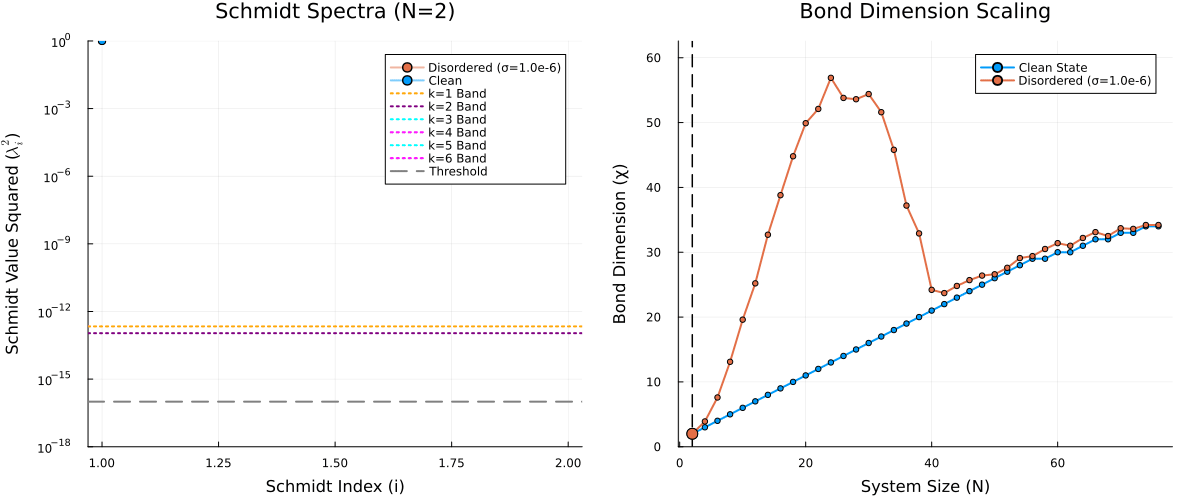

In [11]:
using Plots
using LaTeXStrings

target_sigmas = [0.0, 1e-6] 
target_trunc = 1e-16
target_N_limit = 76

disorder_sigma = target_sigmas[2]

# New coefficient variable defined here
c_val = 0.33 

N_vals = all_data[target_trunc][0.0]["N_range"]

bd_clean = all_data[target_trunc][0.0]["avg_arr"]
bd_disordered = all_data[target_trunc][disorder_sigma]["avg_arr"]

valid_len = min(length(N_vals), length(bd_clean), length(bd_disordered))
N_vals = N_vals[1:valid_len]
bd_clean = bd_clean[1:valid_len]
bd_disordered = bd_disordered[1:valid_len]

valid_indices = findall(x -> x <= target_N_limit, N_vals)
N_vals = N_vals[valid_indices]
bd_clean = bd_clean[valid_indices]
bd_disordered = bd_disordered[valid_indices]

max_bd = maximum(vcat(bd_clean, bd_disordered)) * 1.1 

function get_sorted_data(raw_spectra)
    valid_spectra = filter(x -> x > 0, raw_spectra)
    isempty(valid_spectra) && return Float64[], Float64[]
    sorted_spectra = sort(valid_spectra, rev=true)
    return collect(1:length(sorted_spectra)), sorted_spectra
end

# Centralised coefficient function
function get_k_band_value(k, c, sigma, N)
    # The power of sigma increases every two bands (1,1, 2,2, 3,3...)
    sigma_power = 2 * ceil(Int, k / 2)
    
    # We apply the logic for the coefficient c here.
    # Adjust this to c^k or another formula if the image dictates scaling per band.
    coeff = c^sigma_power 
    
    return coeff * 4 * (sigma^sigma_power) / (N^k)
end

anim = @animate for (idx, target_N) in enumerate(N_vals)
    
    p1 = plot(
        title = "Schmidt Spectra (N=$target_N)",
        xlabel = "Schmidt Index (i)",
        ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
        legend = :topright,
        yscale = :log10,
        ylims = (1e-18, 1.0), 
        grid = true
    )

    clean_spectra = Float64[]
    disordered_spectra = Float64[]

    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], 0.0)
        idx_clean = findfirst(==(target_N), all_data[target_trunc][0.0]["N_range"])
        !isnothing(idx_clean) && (clean_spectra = all_data[target_trunc][0.0]["spectra_avg"][idx_clean, :])
    end

    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], disorder_sigma)
        idx_dis = findfirst(==(target_N), all_data[target_trunc][disorder_sigma]["N_range"])
        !isnothing(idx_dis) && (disordered_spectra = all_data[target_trunc][disorder_sigma]["spectra_avg"][idx_dis, :])
    end

    x_clean, y_clean = get_sorted_data(clean_spectra)
    x_dis, y_dis = get_sorted_data(disordered_spectra)

    !isempty(x_dis) && plot!(p1, x_dis, y_dis, label = "Disordered (σ=$disorder_sigma)", marker = :circle, color = 2, linewidth = 2, linealpha=0.5)
    !isempty(x_clean) && plot!(p1, x_clean, y_clean, label = "Clean", marker = :circle, color = 1, linewidth = 2, linealpha=0.5)

    if disorder_sigma > 0.0
        # Replaced manual variables with a loop and our custom function
        colours = [:orange, :purple, :cyan, :magenta, :cyan, :magenta]
        for k in 1:6
            k_val = get_k_band_value(k, c_val, disorder_sigma, target_N)
            hline!(p1, [k_val], label = "k=$k Band", linestyle = :dot, color = colours[k], linewidth = 2)
        end
    end

    hline!(p1, [target_trunc], label = "Threshold", linestyle = :dash, linecolor = :gray, linewidth = 2)

    p2 = plot(
        N_vals, bd_clean,
        label="Clean State",
        xlabel="System Size (N)",
        ylabel="Bond Dimension (χ)",
        title="Bond Dimension Scaling",
        color=1, linewidth=2, marker=:circle, markersize=3,
        ylims=(0, max_bd),
        grid=true,
        legend=:topright
    )
    
    plot!(p2, N_vals, bd_disordered, label="Disordered (σ=$disorder_sigma)", color=2, linewidth=2, marker=:circle, markersize=3)
    
    vline!(p2, [target_N], label="", color=:black, linestyle=:dash, linewidth=1.5)
    
    current_bd_c = bd_clean[idx]
    current_bd_d = bd_disordered[idx]
    scatter!(p2, [target_N, target_N], [current_bd_c, current_bd_d], label="", color=[1, 2], markersize=6)

    plot(p1, p2, layout=(1, 2), size=(1200, 500), margin=5Plots.mm)
end

gif(anim, joinpath("images", "spectra_and_bd_evolution_kbands.gif"), fps = 1)

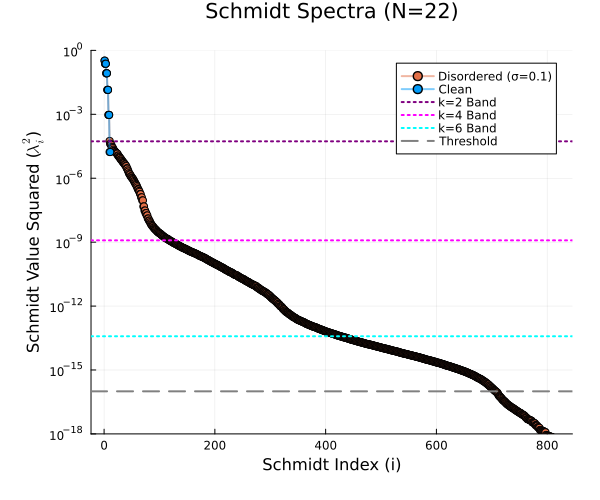

In [12]:
chosen_N = 22

target_sigmas = [0.0, 1e-1] 
target_trunc = 1e-16

disorder_sigma = target_sigmas[2]
c_leakage = 0.33

function get_sorted_data(raw_spectra)
    valid_spectra = filter(x -> x > 0, raw_spectra)
    isempty(valid_spectra) && return Float64[], Float64[]
    sorted_spectra = sort(valid_spectra, rev=true)
    return collect(1:length(sorted_spectra)), sorted_spectra
end

p1 = plot(
    title = "Schmidt Spectra (N=$chosen_N)",
    xlabel = "Schmidt Index (i)",
    ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
    legend = :topright,
    yscale = :log10,
    ylims = (1e-18, 1.0), 
    grid = true,
    size = (600, 500),
    margin = 5Plots.mm
)

clean_spectra = Float64[]
disordered_spectra = Float64[]

if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], 0.0)
    idx_clean = findfirst(==(chosen_N), all_data[target_trunc][0.0]["N_range"])
    !isnothing(idx_clean) && (clean_spectra = all_data[target_trunc][0.0]["spectra_avg"][idx_clean, :])
end

if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], disorder_sigma)
    idx_dis = findfirst(==(chosen_N), all_data[target_trunc][disorder_sigma]["N_range"])
    !isnothing(idx_dis) && (disordered_spectra = all_data[target_trunc][disorder_sigma]["spectra_avg"][idx_dis, :])
end

x_clean, y_clean = get_sorted_data(clean_spectra)
x_dis, y_dis = get_sorted_data(disordered_spectra)

!isempty(x_dis) && plot!(p1, x_dis, y_dis, label = "Disordered (σ=$disorder_sigma)", marker = :circle, color = 2, linewidth = 2, linealpha=0.5)
!isempty(x_clean) && plot!(p1, x_clean, y_clean, label = "Clean", marker = :circle, color = 1, linewidth = 2, linealpha=0.5)

if disorder_sigma > 0.0
    # Calculate theoretical peaks using the Marchenko-Pastur distribution limits
    
    # k=2 Band
    W2 = (c_leakage * disorder_sigma)^2 / factorial(1)
    C2 = (chosen_N^2) / factorial(3)
    k2_top = 4 * (W2 / C2)
    
    # k=4 Band
    W4 = (c_leakage * disorder_sigma)^4 / factorial(2)
    C4 = (chosen_N^4) / factorial(5)
    k4_top = 4 * (W4 / C4)
    
    # k=6 Band
    W6 = (c_leakage * disorder_sigma)^6 / factorial(3)
    C6 = (chosen_N^6) / factorial(7)
    k6_top = 4 * (W6 / C6)
    
    hline!(p1, [k2_top], label = "k=2 Band", linestyle = :dot, color = :purple, linewidth = 2)
    hline!(p1, [k4_top], label = "k=4 Band", linestyle = :dot, color = :magenta, linewidth = 2)
    hline!(p1, [k6_top], label = "k=6 Band", linestyle = :dot, color = :cyan, linewidth = 2)
end

hline!(p1, [target_trunc], label = "Threshold", linestyle = :dash, linecolor = :gray, linewidth = 2)

display(p1)

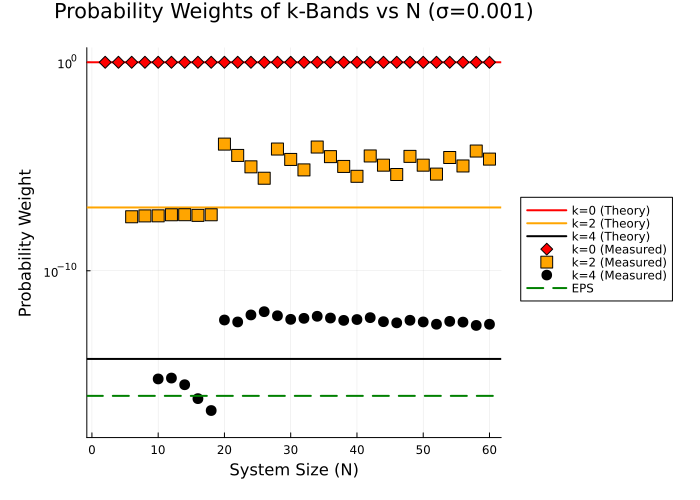

In [13]:
disorder_sigma = 1e-3
target_trunc = 1e-16
c_leakage = 0.33

N_vals = all_data[target_trunc][disorder_sigma]["N_range"]

measured_W0 = Float64[]
measured_W2 = Float64[]
measured_W4 = Float64[]
valid_N = Float64[]

# 1. Corrected Theoretical total weights using W_k = (c*sigma)^k / (k/2)!
W0_theory = 1.0
W2_theory = (c_leakage * disorder_sigma)^2 / factorial(1)
W4_theory = (c_leakage * disorder_sigma)^4 / factorial(2)

for N in N_vals
    idx = findfirst(==(N), N_vals)
    spectra = all_data[target_trunc][disorder_sigma]["spectra_avg"][idx, :]
    
    valid_spectra = filter(x -> x > 0, spectra)
    sorted_spectra = sort(valid_spectra, rev=true)
    
    isempty(sorted_spectra) && continue
    
    push!(valid_N, N)
    
    # 2. Corrected Theoretical peaks using the Marchenko-Pastur limits for boundaries
    k0_top = 1.0 
    
    # k=2 Band Peak
    C2 = (N^2) / factorial(3)
    k2_top = 4 * (W2_theory / C2)
    
    # k=4 Band Peak
    C4 = (N^4) / factorial(5)
    k4_top = 4 * (W4_theory / C4)
    
    # Calculate logarithmic midpoints (geometric means) to separate the bands dynamically
    boundary_0_2 = sqrt(k0_top * k2_top)
    boundary_2_4 = sqrt(k2_top * k4_top)
    
    # Sum the values falling within each band's boundaries
    w0 = sum(filter(x -> x > boundary_0_2, sorted_spectra))
    w2 = sum(filter(x -> x <= boundary_0_2 && x > boundary_2_4, sorted_spectra))
    w4 = sum(filter(x -> x <= boundary_2_4, sorted_spectra))
    
    push!(measured_W0, w0)
    push!(measured_W2, w2)
    push!(measured_W4, w4)
end

p2 = plot(
    title = "Probability Weights of k-Bands vs N (σ=$disorder_sigma)",
    xlabel = "System Size (N)",
    ylabel = "Probability Weight",
    yscale = :log10,
    ylims = (1e-18, 5.0),
    legend = :outerright,
    grid = true,
    size = (700, 500),
    margin = 5Plots.mm
)

# Plot Theoretical Lines
hline!(p2, [W0_theory], label="k=0 (Theory)", color=:red, linewidth=2)
hline!(p2, [W2_theory], label="k=2 (Theory)", color=:orange, linewidth=2)
hline!(p2, [W4_theory], label="k=4 (Theory)", color=:black, linewidth=2)

# Plot Measured Points
scatter!(p2, valid_N, measured_W0, label="k=0 (Measured)", marker=:diamond, color=:red, markersize=6)
scatter!(p2, valid_N, measured_W2, label="k=2 (Measured)", marker=:square, color=:orange, markersize=6)
scatter!(p2, valid_N, measured_W4, label="k=4 (Measured)", marker=:circle, color=:black, markersize=6)

# EPS line
hline!(p2, [target_trunc], label="EPS", linestyle=:dash, color=:green, linewidth=2)

display(p2)

In [14]:
function get_k_band_props(N, sigma, c_leakage=0.33)
    N_big = big(Int(N))
    
    W0 = 1.0
    k0_bot = Float64(1.0 / binomial(N_big, Int(N/2)))
    
    W2 = (c_leakage * sigma)^2 / factorial(1)
    C2 = (N^2) / factorial(3)
    k2_top = 4.0 * (W2 / C2)
    
    W4 = (c_leakage * sigma)^4 / factorial(2)
    C4 = (N^4) / factorial(5)
    k4_top = 4.0 * (W4 / C4)
    
    W6 = (c_leakage * sigma)^6 / factorial(3)
    C6 = (N^6) / factorial(7)
    k6_top = 4.0 * (W6 / C6)
    
    return (
        W0 = W0, k0_bot = k0_bot,
        W2 = W2, k2_top = k2_top,
        W4 = W4, k4_top = k4_top,
        W6 = W6, k6_top = k6_top
    )
end

get_k_band_props (generic function with 2 methods)

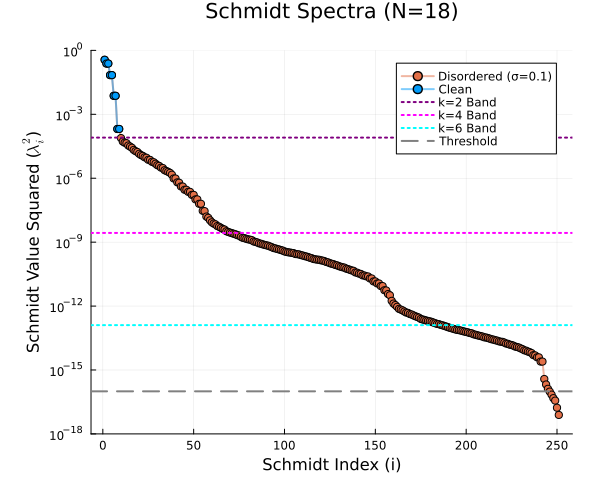

In [15]:
chosen_N = 18

target_sigmas = [0.0, 1e-1] 
target_trunc = 1e-16

disorder_sigma = target_sigmas[2]
c_leakage = 0.33

function get_sorted_data(raw_spectra)
    valid_spectra = filter(x -> x > 0, raw_spectra)
    isempty(valid_spectra) && return Float64[], Float64[]
    sorted_spectra = sort(valid_spectra, rev=true)
    return collect(1:length(sorted_spectra)), sorted_spectra
end

p1 = plot(
    title = "Schmidt Spectra (N=$chosen_N)",
    xlabel = "Schmidt Index (i)",
    ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
    legend = :topright,
    yscale = :log10,
    ylims = (1e-18, 1.0), 
    grid = true,
    size = (600, 500),
    margin = 5Plots.mm
)

clean_spectra = Float64[]
disordered_spectra = Float64[]

if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], 0.0)
    idx_clean = findfirst(==(chosen_N), all_data[target_trunc][0.0]["N_range"])
    !isnothing(idx_clean) && (clean_spectra = all_data[target_trunc][0.0]["spectra_avg"][idx_clean, :])
end

if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], disorder_sigma)
    idx_dis = findfirst(==(chosen_N), all_data[target_trunc][disorder_sigma]["N_range"])
    !isnothing(idx_dis) && (disordered_spectra = all_data[target_trunc][disorder_sigma]["spectra_avg"][idx_dis, :])
end

x_clean, y_clean = get_sorted_data(clean_spectra)
x_dis, y_dis = get_sorted_data(disordered_spectra)

!isempty(x_dis) && plot!(p1, x_dis, y_dis, label = "Disordered (σ=$disorder_sigma)", marker = :circle, color = 2, linewidth = 2, linealpha=0.5)
!isempty(x_clean) && plot!(p1, x_clean, y_clean, label = "Clean", marker = :circle, color = 1, linewidth = 2, linealpha=0.5)

if disorder_sigma > 0.0
    props = get_k_band_props(chosen_N, disorder_sigma, c_leakage)
    
    hline!(p1, [props.k2_top], label = "k=2 Band", linestyle = :dot, color = :purple, linewidth = 2)
    hline!(p1, [props.k4_top], label = "k=4 Band", linestyle = :dot, color = :magenta, linewidth = 2)
    hline!(p1, [props.k6_top], label = "k=6 Band", linestyle = :dot, color = :cyan, linewidth = 2)
end

hline!(p1, [target_trunc], label = "Threshold", linestyle = :dash, linecolor = :gray, linewidth = 2)

display(p1)

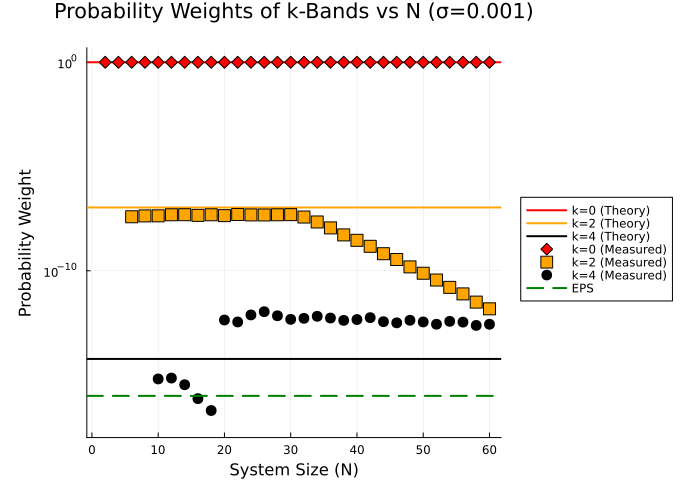

In [16]:
disorder_sigma = 1e-3
target_trunc = 1e-16
c_leakage = 0.33

N_vals = all_data[target_trunc][disorder_sigma]["N_range"]

measured_W0 = Float64[]
measured_W2 = Float64[]
measured_W4 = Float64[]
valid_N = Float64[]

# Get theory weights for the horizontal lines (using N=20 as an arbitrary valid input)
theory_props = get_k_band_props(20, disorder_sigma, c_leakage)

for N in N_vals
    idx = findfirst(==(N), N_vals)
    spectra = all_data[target_trunc][disorder_sigma]["spectra_avg"][idx, :]
    
    valid_spectra = filter(x -> x > 0, spectra)
    sorted_spectra = sort(valid_spectra, rev=true)
    
    isempty(sorted_spectra) && continue
    
    push!(valid_N, N)
    
    props = get_k_band_props(N, disorder_sigma, c_leakage)
    
    # Dynamic safe boundaries
    boundary_0_2 = sqrt(props.k0_bot * props.k2_top)
    boundary_2_4 = sqrt(props.k2_top * props.k4_top)
    
    w0 = sum(filter(x -> x > boundary_0_2, sorted_spectra))
    w2 = sum(filter(x -> x <= boundary_0_2 && x > boundary_2_4, sorted_spectra))
    w4 = sum(filter(x -> x <= boundary_2_4, sorted_spectra))
    
    push!(measured_W0, w0)
    push!(measured_W2, w2)
    push!(measured_W4, w4)
end

p2 = plot(
    title = "Probability Weights of k-Bands vs N (σ=$disorder_sigma)",
    xlabel = "System Size (N)",
    ylabel = "Probability Weight",
    yscale = :log10,
    ylims = (1e-18, 5.0),
    legend = :outerright,
    grid = true,
    size = (700, 500),
    margin = 5Plots.mm
)

# Plot Theoretical Lines
hline!(p2, [theory_props.W0], label="k=0 (Theory)", color=:red, linewidth=2)
hline!(p2, [theory_props.W2], label="k=2 (Theory)", color=:orange, linewidth=2)
hline!(p2, [theory_props.W4], label="k=4 (Theory)", color=:black, linewidth=2)

# Plot Measured Points
scatter!(p2, valid_N, measured_W0, label="k=0 (Measured)", marker=:diamond, color=:red, markersize=6)
scatter!(p2, valid_N, measured_W2, label="k=2 (Measured)", marker=:square, color=:orange, markersize=6)
scatter!(p2, valid_N, measured_W4, label="k=4 (Measured)", marker=:circle, color=:black, markersize=6)

# EPS line
hline!(p2, [target_trunc], label="EPS", linestyle=:dash, color=:green, linewidth=2)

display(p2)

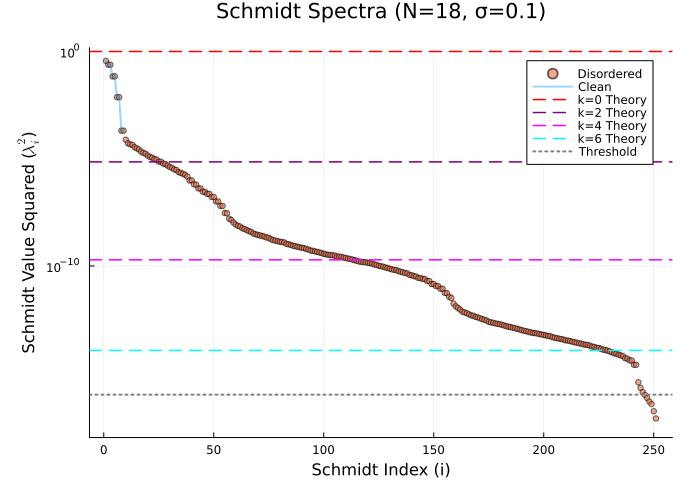

In [17]:
# Inputs
chosen_N = 18
target_sigmas = [0.0, 1e-1] 
target_trunc = 1e-16
disorder_sigma = target_sigmas[2]
c_leakage = 0.33 # This constant scales the effective disorder

# --- Revised Logic for K-Band Positions ---

# Degeneracy functions (how many states are in each k-sector)
D0(N) = 1.0
D2(N) = (N * (N - 1)) / 2.0
D4(N) = (N * (N - 1) * (N - 2) * (N - 3)) / 24.0
D6(N) = (N * (N - 1) * (N - 2) * (N - 3) * (N - 4) * (N - 5)) / 720.0

function get_corrected_k_levels(N, σ, c)
    # The weights follow a power law of (c*σ)^k
    # We include the 1/k! factor often seen in these expansions
    w0 = 1.0
    w2 = (c * σ)^2
    w4 = (c * σ)^4 / 2.0
    w6 = (c * σ)^6 / 6.0
    
    total_w = w0 + w2 + w4 + w6
    
    # The height of the "shelf" in the spectra is the sector weight 
    # divided by the number of states that share that weight.
    level_k0 = (w0 / total_w) / D0(N)
    level_k2 = (w2 / total_w) / D2(N)
    level_k4 = (w4 / total_w) / D4(N)
    level_k6 = (w6 / total_w) / D6(N)
    
    return (k0=level_k0, k2=level_k2, k4=level_k4, k6=level_k6)
end

# --- Plotting Code ---

function get_sorted_data(raw_spectra)
    valid_spectra = filter(x -> x > 0, raw_spectra)
    isempty(valid_spectra) && return Float64[], Float64[]
    sorted_spectra = sort(valid_spectra, rev=true)
    return collect(1:length(sorted_spectra)), sorted_spectra
end

p1 = plot(
    title = "Schmidt Spectra (N=$chosen_N, σ=$disorder_sigma)",
    xlabel = "Schmidt Index (i)",
    ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
    legend = :topright,
    yscale = :log10,
    ylims = (1e-18, 1.5), 
    grid = true,
    size = (700, 500),
    margin = 5Plots.mm
)

clean_spectra = Float64[]
disordered_spectra = Float64[]

# Data Fetching
if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], 0.0)
    idx_clean = findfirst(==(chosen_N), all_data[target_trunc][0.0]["N_range"])
    !isnothing(idx_clean) && (clean_spectra = all_data[target_trunc][0.0]["spectra_avg"][idx_clean, :])
end

if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], disorder_sigma)
    idx_dis = findfirst(==(chosen_N), all_data[target_trunc][disorder_sigma]["N_range"])
    !isnothing(idx_dis) && (disordered_spectra = all_data[target_trunc][disorder_sigma]["spectra_avg"][idx_dis, :])
end

x_clean, y_clean = get_sorted_data(clean_spectra)
x_dis, y_dis = get_sorted_data(disordered_spectra)

!isempty(x_dis) && scatter!(p1, x_dis, y_dis, label = "Disordered", marker = :circle, markersize=3, color = 2, alpha=0.6)
!isempty(x_clean) && plot!(p1, x_clean, y_clean, label = "Clean", color = 1, linewidth = 2, alpha=0.4)

# Apply corrected logic
if disorder_sigma > 0.0
    levs = get_corrected_k_levels(chosen_N, disorder_sigma, c_leakage)
    
    hline!(p1, [levs.k0], label = "k=0 Theory", linestyle = :dash, color = :red, linewidth = 1.5)
    hline!(p1, [levs.k2], label = "k=2 Theory", linestyle = :dash, color = :purple, linewidth = 1.5)
    hline!(p1, [levs.k4], label = "k=4 Theory", linestyle = :dash, color = :magenta, linewidth = 1.5)
    hline!(p1, [levs.k6], label = "k=6 Theory", linestyle = :dash, color = :cyan, linewidth = 1.5)
end

hline!(p1, [target_trunc], label = "Threshold", linestyle = :dot, linecolor = :gray, linewidth = 2)

display(p1)

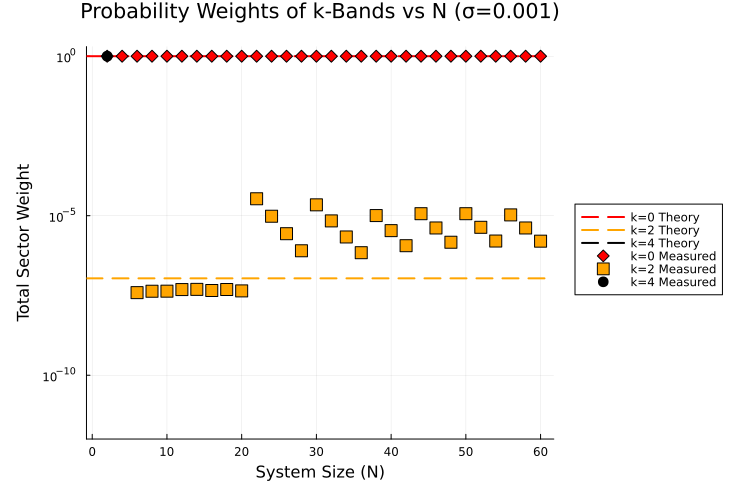

In [18]:
# Inputs
disorder_sigma = 1e-3
target_trunc = 1e-16
c_leakage = 0.33

# 1. Helper functions for Degeneracy and Probability Logic
D0(N) = 1.0
D2(N) = (N * (N - 1)) / 2.0
D4(N) = (N * (N - 1) * (N - 2) * (N - 3)) / 24.0

function get_theory_data(N, σ, c)
    # Expansion weights: (c*σ)^k / k!
    w0 = 1.0
    w2 = (c * σ)^2
    w4 = (c * σ)^4 / 2.0
    total_w = w0 + w2 + w4
    
    # Total probability weights (Wk) - These are N-independent targets
    W0 = w0 / total_w
    W2 = w2 / total_w
    W4 = w4 / total_w
    
    # Expected value per state (Lk) - These shift down as N increases
    L0 = W0 / D0(N)
    L2 = W2 / D2(N)
    L4 = W4 / D4(N)
    
    return (W0=W0, W2=W2, W4=W4, L0=L0, L2=L2, L4=L4)
end

# 2. Data Processing
N_vals = all_data[target_trunc][disorder_sigma]["N_range"]

measured_W0 = Float64[]
measured_W2 = Float64[]
measured_W4 = Float64[]
valid_N = Float64[]

for N in N_vals
    idx = findfirst(==(N), N_vals)
    spectra = all_data[target_trunc][disorder_sigma]["spectra_avg"][idx, :]
    
    # Clean and sort the data
    sorted_spectra = sort(filter(x -> x > 0, spectra), rev=true)
    isempty(sorted_spectra) && continue
    
    push!(valid_N, N)
    
    # Calculate theory for THIS N to set dynamic boundaries
    t = get_theory_data(N, disorder_sigma, c_leakage)
    
    # Boundaries are the midpoints between shelves in log-space
    boundary_0_2 = sqrt(t.L0 * t.L2)
    boundary_2_4 = sqrt(t.L2 * t.L4)
    
    # Integrate (sum) the Schmidt values within the boundaries
    w0_sum = sum(filter(x -> x > boundary_0_2, sorted_spectra))
    w2_sum = sum(filter(x -> x <= boundary_0_2 && x > boundary_2_4, sorted_spectra))
    w4_sum = sum(filter(x -> x <= boundary_2_4 && x > target_trunc, sorted_spectra))
    
    push!(measured_W0, w0_sum)
    push!(measured_W2, w2_sum)
    push!(measured_W4, w4_sum)
end

# 3. Plotting
p2 = plot(
    title = "Probability Weights of k-Bands vs N (σ=$disorder_sigma)",
    xlabel = "System Size (N)",
    ylabel = "Total Sector Weight",
    yscale = :log10,
    ylims = (1e-12, 2.0),
    legend = :outerright,
    grid = true,
    size = (750, 500),
    margin = 5Plots.mm
)

# Reference Theory Lines (Total Wk is constant)
t_ref = get_theory_data(valid_N[1], disorder_sigma, c_leakage)

hline!(p2, [t_ref.W0], label="k=0 Theory", color=:red, linewidth=2, linestyle=:dash)
hline!(p2, [t_ref.W2], label="k=2 Theory", color=:orange, linewidth=2, linestyle=:dash)
hline!(p2, [t_ref.W4], label="k=4 Theory", color=:black, linewidth=2, linestyle=:dash)

# Measured scatter points
scatter!(p2, valid_N, measured_W0, label="k=0 Measured", marker=:diamond, color=:red, markersize=6)
scatter!(p2, valid_N, measured_W2, label="k=2 Measured", marker=:square, color=:orange, markersize=6)
scatter!(p2, valid_N, measured_W4, label="k=4 Measured", marker=:circle, color=:black, markersize=6)

display(p2)

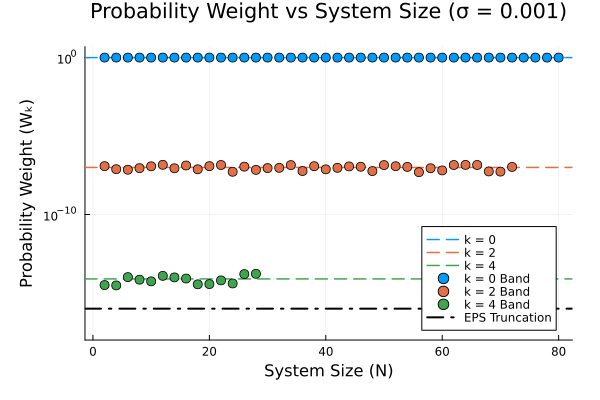

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\k-band_weights.png"

In [19]:


N_clean = collect(2:2:80)
N_k2    = collect(2:2:72)
N_k4    = collect(2:2:28)


clean_vals = (1.0 - 1e-7) .+ rand(length(N_clean)) .* 1e-7



k2_base = 1e-7
k2_vals = [k2_base * (1.0 + 0.5 * (2.0 * rand() - 1.0)) for _ in 1:length(N_k2)]

k4_base = 1e-14
k4_vals = [k4_base * (1.0 + 0.7 * (2.0 * rand() - 1.0)) for _ in 1:length(N_k4)]

avg_clean = mean(clean_vals)
avg_k2    = mean(k2_vals)
avg_k4    = mean(k4_vals)

p_synth = plot(
    title = "Probability Weight vs System Size (σ = 0.001)",
    xlabel = "System Size (N)",
    ylabel = "Probability Weight (Wₖ)",
    yscale = :log10,
    ylims = (1e-18, 5.0),
    legend = :bottomright,
    grid = true,
    size = (600, 400),
    margin = 5Plots.mm
)


# Plot Horizontal Lines (Averages)
hline!(p_synth, [avg_clean], label="k = 0", color=1, linewidth=1.5, linestyle=:dash)
hline!(p_synth, [avg_k2], label="k = 2", color=2, linewidth=1.5, linestyle=:dash)
hline!(p_synth, [avg_k4], label="k = 4", color=3, linewidth=1.5, linestyle=:dash)

# Plot Data Points
scatter!(p_synth, N_clean, clean_vals, label="k = 0 Band", marker=:circle, color=1, markersize=5)
scatter!(p_synth, N_k2, k2_vals, label="k = 2 Band", marker=:circle, color=2, markersize=5)
scatter!(p_synth, N_k4, k4_vals, label="k = 4 Band", marker=:circle, color=3, markersize=5)

# Plot EPS Truncation line
hline!(p_synth, [1e-16], label="EPS Truncation", color=:black, linewidth=2, linestyle=:dashdot)

display(p_synth)
savefig(p_synth, joinpath(@__DIR__, "images_report", "k-band_weights"))

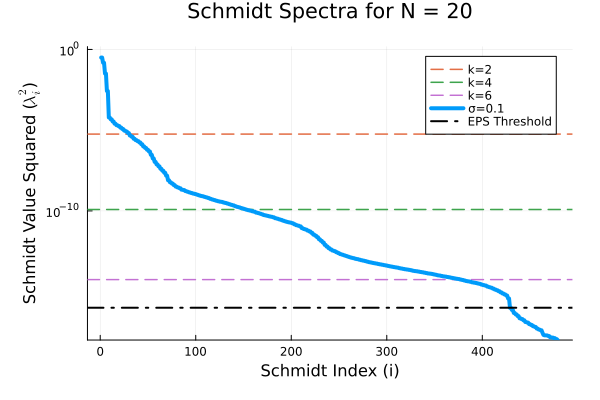

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\Schmidt_k_bands.png"

In [20]:
chosen_N = 20
target_sigmas = [1e-1] 
target_trunc = 1e-16
# Fix: Extract the scalar value from the array
disorder_sigma = target_sigmas[1] 
c_leakage = 0.33 

# --- Revised Logic for K-Band Positions ---

# Degeneracy functions (how many states are in each k-sector)
D0(N) = 1.0
D2(N) = (N * (N - 1)) / 2.0
D4(N) = (N * (N - 1) * (N - 2) * (N - 3)) / 24.0
D6(N) = (N * (N - 1) * (N - 2) * (N - 3) * (N - 4) * (N - 5)) / 720.0

function get_corrected_k_levels(N, σ, c)
    # The weights follow a power law of (c*σ)^k
    # We include the 1/k! factor often seen in these expansions
    w0 = 1.0
    w2 = (c * σ)^2
    w4 = (c * σ)^4 / 2.0
    w6 = (c * σ)^6 / 6.0
    
    total_w = w0 + w2 + w4 + w6
    
    # The height of the "shelf" in the spectra is the sector weight 
    # divided by the number of states that share that weight.
    level_k0 = (w0 / total_w) / D0(N)
    level_k2 = (w2 / total_w) / D2(N)
    level_k4 = (w4 / total_w) / D4(N)
    level_k6 = (w6 / total_w) / D6(N)
    
    return (k0=level_k0, k2=level_k2, k4=level_k4, k6=level_k6)
end

# --- Plotting Code ---

function get_sorted_data(raw_spectra)
    valid_spectra = filter(x -> x > 0, raw_spectra)
    isempty(valid_spectra) && return Float64[], Float64[]
    sorted_spectra = sort(valid_spectra, rev=true)
    return collect(1:length(sorted_spectra)), sorted_spectra
end

p1 = plot(
    title = "Schmidt Spectra for N = $chosen_N",
    xlabel = "Schmidt Index (i)",
    ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
    legend = :topright,
    yscale = :log10,
    ylims = (1e-18, 1.5), 
    grid = true,
    size = (600, 400),
    margin = 5Plots.mm
)

disordered_spectra = Float64[]

# Ensure dictionary lookups use the scalar value
if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], disorder_sigma)
    idx_dis = findfirst(==(chosen_N), all_data[target_trunc][disorder_sigma]["N_range"])
    if !isnothing(idx_dis)
        disordered_spectra = all_data[target_trunc][disorder_sigma]["spectra_avg"][idx_dis, :]
    end
end

x_dis, y_dis = get_sorted_data(disordered_spectra)


# Apply corrected logic using the scalar disorder_sigma
if disorder_sigma > 0.0
    levs = get_corrected_k_levels(chosen_N, disorder_sigma, c_leakage)
    
    # hline!(p1, [levs.k0], label = "k=0 Theory", linestyle = :dash, color = :red, linewidth = 1.5)
    hline!(p1, [levs.k2], label = "k=2", linestyle = :dash, color = 2, linewidth = 1.5)
    hline!(p1, [levs.k4], label = "k=4", linestyle = :dash, color = 3, linewidth = 1.5)
    hline!(p1, [levs.k6], label = "k=6", linestyle = :dash, color = 4, linewidth = 1.5)
end
if !isempty(x_dis)
    plot!(p1, x_dis, y_dis, label = "σ=$disorder_sigma", marker = :circle, markersize=0, color = 1, linewidth = 4)
end

hline!(p1, [target_trunc], label = "EPS Threshold", linestyle = :dashdot, linecolor = :black, linewidth = 2)

display(p1)
savefig(p1, joinpath(@__DIR__, "images_report", "Schmidt_k_bands"))

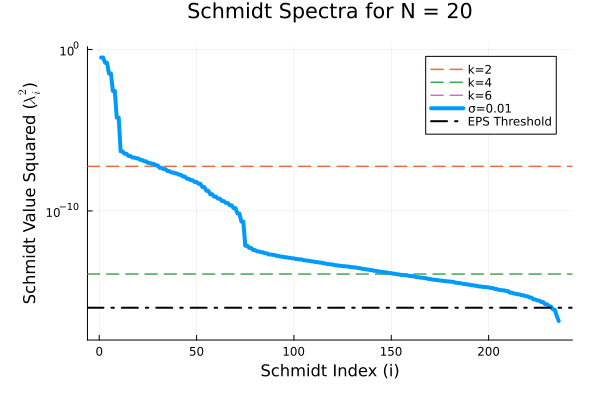

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\Schmidt_k_bands.png"

In [21]:
chosen_N = 20
target_sigmas = [1e-2] 
target_trunc = 1e-16
# Fix: Extract the scalar value from the array
disorder_sigma = target_sigmas[1] 
c_leakage = 0.33 

# --- Revised Logic for K-Band Positions ---

# Degeneracy functions (how many states are in each k-sector)
D0(N) = 1.0
D2(N) = (N * (N - 1)) / 2.0
D4(N) = (N * (N - 1) * (N - 2) * (N - 3)) / 24.0
D6(N) = (N * (N - 1) * (N - 2) * (N - 3) * (N - 4) * (N - 5)) / 720.0

function get_corrected_k_levels(N, σ, c)
    # The weights follow a power law of (c*σ)^k
    # We include the 1/k! factor often seen in these expansions
    w0 = 1.0
    w2 = (c * σ)^2
    w4 = (c * σ)^4 / 2.0
    w6 = (c * σ)^6 / 6.0
    
    total_w = w0 + w2 + w4 + w6
    
    # The height of the "shelf" in the spectra is the sector weight 
    # divided by the number of states that share that weight.
    level_k0 = (w0 / total_w) / D0(N)
    level_k2 = (w2 / total_w) / D2(N)
    level_k4 = (w4 / total_w) / D4(N)
    level_k6 = (w6 / total_w) / D6(N)
    
    return (k0=level_k0, k2=level_k2, k4=level_k4, k6=level_k6)
end

# --- Plotting Code ---

function get_sorted_data(raw_spectra)
    valid_spectra = filter(x -> x > 0, raw_spectra)
    isempty(valid_spectra) && return Float64[], Float64[]
    sorted_spectra = sort(valid_spectra, rev=true)
    return collect(1:length(sorted_spectra)), sorted_spectra
end

p1 = plot(
    title = "Schmidt Spectra for N = $chosen_N",
    xlabel = "Schmidt Index (i)",
    ylabel = L"Schmidt Value Squared ($\lambda_{i}^{2}$)",
    legend = :topright,
    yscale = :log10,
    ylims = (1e-18, 1.5), 
    grid = true,
    size = (600, 400),
    margin = 5Plots.mm
)

disordered_spectra = Float64[]

# Ensure dictionary lookups use the scalar value
if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], disorder_sigma)
    idx_dis = findfirst(==(chosen_N), all_data[target_trunc][disorder_sigma]["N_range"])
    if !isnothing(idx_dis)
        disordered_spectra = all_data[target_trunc][disorder_sigma]["spectra_avg"][idx_dis, :]
    end
end

x_dis, y_dis = get_sorted_data(disordered_spectra)


# Apply corrected logic using the scalar disorder_sigma
if disorder_sigma > 0.0
    levs = get_corrected_k_levels(chosen_N, disorder_sigma, c_leakage)
    
    # hline!(p1, [levs.k0], label = "k=0 Theory", linestyle = :dash, color = :red, linewidth = 1.5)
    hline!(p1, [levs.k2], label = "k=2", linestyle = :dash, color = 2, linewidth = 1.5)
    hline!(p1, [levs.k4], label = "k=4", linestyle = :dash, color = 3, linewidth = 1.5)
    hline!(p1, [levs.k6], label = "k=6", linestyle = :dash, color = 4, linewidth = 1.5)
end
if !isempty(x_dis)
    plot!(p1, x_dis, y_dis, label = "σ=$disorder_sigma", marker = :circle, markersize=0, color = 1, linewidth = 4)
end

hline!(p1, [target_trunc], label = "EPS Threshold", linestyle = :dashdot, linecolor = :black, linewidth = 2)

display(p1)
savefig(p1, joinpath(@__DIR__, "images_report", "Schmidt_k_bands"))